<font size="+3"><strong>Telco Customer Churn</strong></font>

# Classification Model: Logistic Regression 


### About Dataset

#### Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

#### Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

**The data set includes information about:**

-- Customers who left within the last month – the column is called Churn

-- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies.

-- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges.

-- Demographic info about customers – gender, age range, and if they have partners and dependents.

## Import Libraries 

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from category_encoders import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted

Load data to see the first 5 rows and the data info.

In [11]:
df = pd.read_csv("Desktop/Data Set Project Practice/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [396]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Create Binary Target for our Target vector **Churn**. That is changing the column from **Yes** / **No** to **1** / **2**.

In [398]:
# Creat Binary Target 
df["Churn"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

Convert "TotalCharges" column from an **object** datatype to **float** datatype

In [400]:
# Convert "TotalCharges" column to floating point numbers
df["TotalCharges"] = df["TotalCharges"].replace(' ', np.nan)
df["TotalCharges"] = df["TotalCharges"].astype(float)
df["TotalCharges"].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

Check for Multicollinearity 

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.102411,0.150889
tenure,0.016567,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn,0.150889,-0.352229,0.193356,-0.199484,1.000000


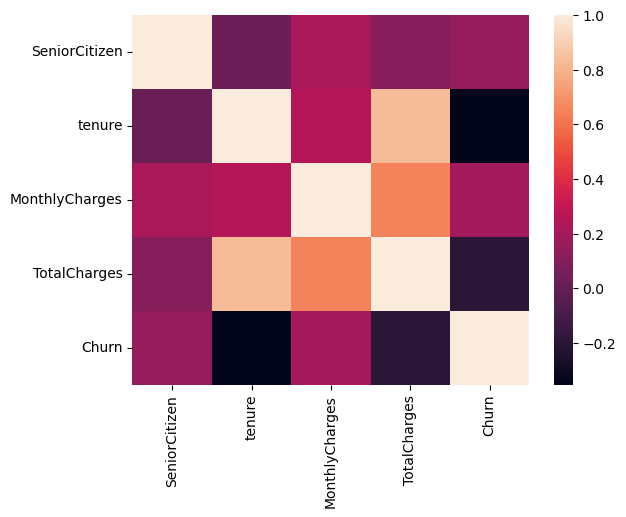

In [402]:
correlation = df.select_dtypes("number").corr()
sns.heatmap(correlation);
correlation

So let's look at the columns with number datatypes and check which one between **tenure** and **TotalCharges**, that we can drop.

In [404]:
df.select_dtypes("number").info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SeniorCitizen   7043 non-null   int64  
 1   tenure          7043 non-null   int64  
 2   MonthlyCharges  7043 non-null   float64
 3   TotalCharges    7032 non-null   float64
 4   Churn           7043 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 275.2 KB


Since **TotalCharges** column has more nulls or NAN, let us drop it.

In [406]:
# Drop Multicollinearity column ("TotalCharges")
df.drop(columns="TotalCharges", inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Put all the wrangle and cleaning process in a function.

## Create a Function to Load and Clean Data

In [409]:
def wrangle(filepath):
    # Read data as csv file
    df = pd.read_csv(filepath)

    # Creat Binary Target 
    df["Churn"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

    # Convert "TotalCharges" column to floating point numbers
    df["TotalCharges"] = df["TotalCharges"].replace(' ', np.nan)
    df["TotalCharges"] = df["TotalCharges"].astype(float)

    # Drop Multicollinearity column ("TotalCharges")
    df.drop(columns="TotalCharges", inplace=True)

    # Display all columns
    pd.set_option("display.max_columns", None)

    return df

In [410]:
df = wrangle("Desktop/Data Set Project Practice/Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 20)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,1


## Explore

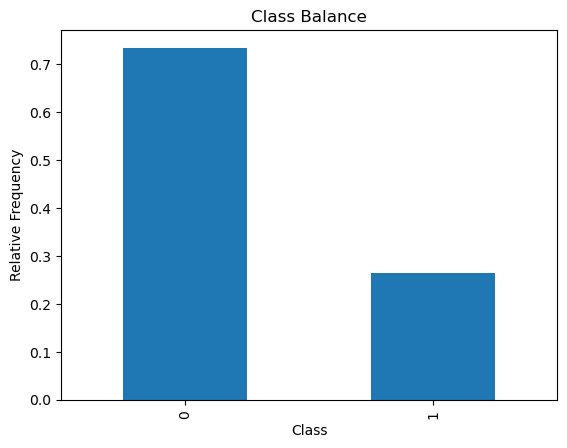

In [412]:
# Plot of Class balance for Churn
df["Churn"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Relative Frequency")
plt.title("Class Balance");

In [413]:
# Create Two variables for the "Not Churn" and "Churn Out" Class Proportion of the Class Balance
not_churn_prop, churn_out_prop = df["Churn"].value_counts(normalize=True).round(3)
print("Not Churn Proportion:", not_churn_prop)
print("Churn Out Proportion:", churn_out_prop)

Not Churn Proportion: 0.735
Churn Out Proportion: 0.265


Create a pivot table for some of the categorical variables and average churn to see how they affect the churn rate.

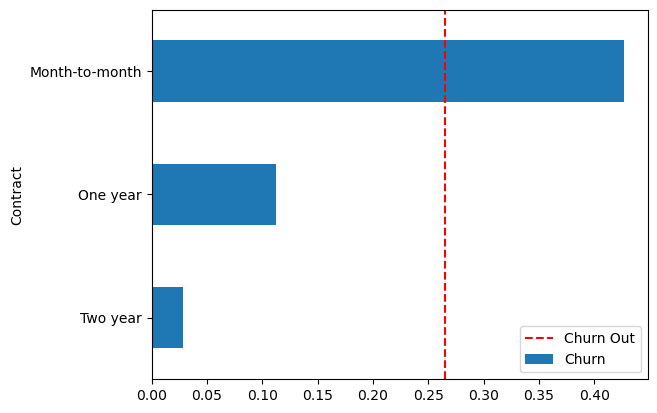

In [415]:
# Pivot table for Contract and Churn
Contract = pd.pivot_table(
    df,
    index="Contract",
    values="Churn",
    aggfunc="mean"
).sort_values(by="Churn")
Contract.plot(kind="barh")
plt.axvline(churn_out_prop, linestyle="--", color="red", label="Churn Out")
plt.legend(loc="lower right");

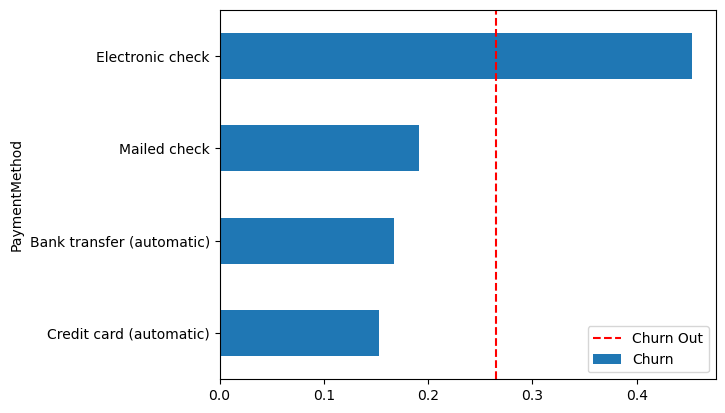

In [416]:
# Pivot table for PaymentMethod and Churn
PaymentMethod = pd.pivot_table(
    df,
    index="PaymentMethod",
    values="Churn",
    aggfunc="mean"
).sort_values(by="Churn")
PaymentMethod.plot(kind="barh")
plt.axvline(churn_out_prop, linestyle="--", color="red", label="Churn Out")
plt.legend(loc="lower right");

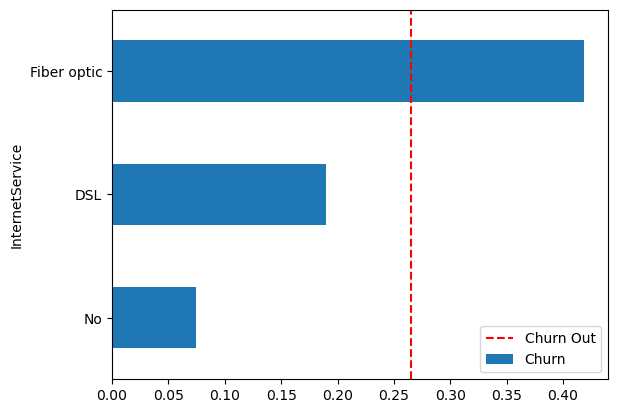

In [417]:
# Pivot table for InternetService and Churn
InternetService = pd.pivot_table(
    df,
    index="InternetService",
    values="Churn",
    aggfunc="mean"
).sort_values(by="Churn")
InternetService.plot(kind="barh")
plt.axvline(churn_out_prop, linestyle="--", color="red", label="Churn Out")
plt.legend(loc="lower right");

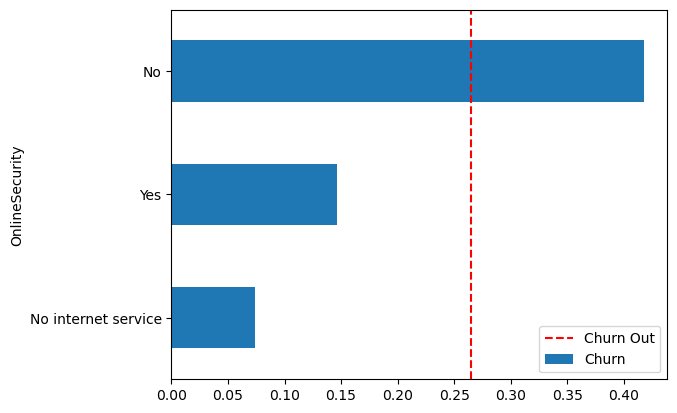

In [418]:
# Pivot table for OnlineSecurity and Churn
OnlineSecurity = pd.pivot_table(
    df,
    index="OnlineSecurity",
    values="Churn",
    aggfunc="mean"
).sort_values(by="Churn")
OnlineSecurity.plot(kind="barh")
plt.axvline(churn_out_prop, linestyle="--", color="red", label="Churn Out")
plt.legend(loc="lower right");

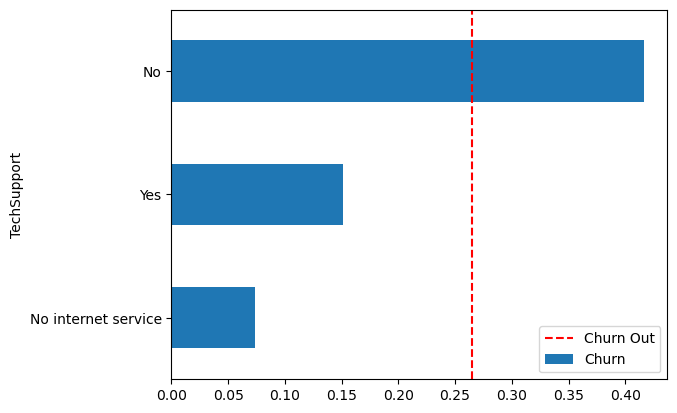

In [419]:
# Pivot table for TechSupport and Churn
TechSupport = pd.pivot_table(
    df,
    index="TechSupport",
    values="Churn",
    aggfunc="mean"
).sort_values(by="Churn")
TechSupport.plot(kind="barh")
plt.axvline(churn_out_prop, linestyle="--", color="red", label="Churn Out")
plt.legend(loc="lower right");

I feel like the column "MonthlyCharges" may affect Churn. Anyway, let's see if there is a relationship between the two. If MonthlyCharges will affect Churn

In [421]:
df["Churn"].corr(df["MonthlyCharges"]).round(3)

0.193

The correlation coefficient is very low **0.193**, much less that 0.5, hence no relationship.

## Split

In [424]:
# Create feature matrix and target vector
target = "Churn"
y = df[target].apply(lambda x: "Yes" if x==1 else "No")
X = df.drop(columns=target)

# Save "customerID" separately 
customer_id = X["customerID"]

# Drop it from X before training so that it won't cause leakages or act as high cardinality features
X = X.drop("customerID", axis=1)
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70


Divide the data (X, y, customer_id) into training and test sets using a randomized train-test split. Test set will be 20% of total data. And we will set a random_state to 42 for reproducibility.

In [426]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_id, test_size=0.2, random_state=42
)
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)
print("id_train Shape:", id_train.shape)
print("id_test Shape:", id_test.shape)

X_train Shape: (5634, 18)
y_train Shape: (5634,)
X_test Shape: (1409, 18)
y_test Shape: (1409,)
id_train Shape: (5634,)
id_test Shape: (1409,)


## Build Model

I will be using Logistic Regression for this Project.

In [429]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.73


## Iterate

I will now create a pipeline named model that contains a `OneHotEncoder` transformer and a `LogisticRegression` predictor. I will set the `use_cat_names` argument for my transformer to **True**, also for the `LogisticRegression`, set `max_iter` to **1000**. Then fit it to the training data.

In [432]:
# Build Model
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LogisticRegression(max_iter=1000)
)
# Fit it to the Training Data
model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['gender', 'Partner', 'Dependents',
                                     'PhoneService', 'MultipleLines',
                                     'InternetService', 'OnlineSecurity',
                                     'OnlineBackup', 'DeviceProtection',
                                     'TechSupport', 'StreamingTV',
                                     'StreamingMovies', 'Contract',
                                     'PaperlessBilling', 'PaymentMethod'],
                               use_cat_names=True)),
                ('logisticregression', LogisticRegression(max_iter=1000))])

## Evaluate

 Calculating the training and test accuracy scores for models.

In [435]:
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = accuracy_score(y_test, model.predict(X_test))
print("Training Accuracy:", round(acc_train, 2))
print("Test Accuracy:", round(acc_test, 2))

Training Accuracy: 0.8
Test Accuracy: 0.82


So our Training and Test Accuracies beat the Baseline Accuracy, so our model is good to go. 

## Communicate

Printing the first 5 predictions for the class labels and the probabilities for each class labels, we have.

In [439]:
y_train_pred = model.predict(X_train)
y_train_pred_prob = model.predict_proba(X_train)
print("First 5 Predictions for Class label:", y_train_pred[:5])
print("First 5 Predicted Probabilities:", y_train_pred_prob[:5])

First 5 Predictions for Class label: ['No' 'No' 'Yes' 'Yes' 'No']
First 5 Predicted Probabilities: [[0.90589378 0.09410622]
 [0.87097145 0.12902855]
 [0.38275402 0.61724598]
 [0.34224133 0.65775867]
 [0.92655676 0.07344324]]


Let's see the first 10 Customers that will Churn as Predicted from our model using the trained data and compare this to their actual churn seen initially from the data.

In [441]:
results = pd.DataFrame(
    {
        "customerID": id_train,
        "Actual Churn": y_train,
        "Predicted Churn": y_train_pred
    }
)
results.set_index("customerID", inplace=True)
results.head(10)

,Actual Churn,Predicted Churn
customerID,,
4223-BKEOR,No,No
6035-RIIOM,No,No
3797-VTIDR,Yes,Yes
2568-BRGYX,Yes,Yes
2775-SEFEE,No,No
4291-SHSBH,No,Yes
4635-EJYPD,No,No
2607-DHDAK,No,No
5204-QZXPU,Yes,Yes


Let's test this using our test set.

In [443]:
y_test_pred = model.predict(X_test)
pred_test_data = pd.DataFrame(
    {
        "customerID": id_test,
        "Actual Churn": y_test,
        "Predicted Churn": y_test_pred
    }
)
pred_test_data.set_index("customerID", inplace=True)
pred_test_data.head(10)

,Actual Churn,Predicted Churn
customerID,,
1024-GUALD,Yes,Yes
0484-JPBRU,No,No
3620-EHIMZ,No,No
6910-HADCM,Yes,Yes
8587-XYZSF,No,No
6818-WOBHJ,Yes,No
3082-YVEKW,No,No
4737-AQCPU,No,No
4853-RULSV,Yes,No


### Results

We will extract the feature names and importances from our model.

In [446]:
features = model.named_steps["onehotencoder"].get_feature_names_out()
importances = model.named_steps["logisticregression"].coef_[0]

We will create a pandas Series named odds_ratios, where the index is features and the values are the exponential of the importances.

In [448]:
feat_impt = pd.Series(importances, index=features).sort_values()
feat_impt.tail()

PaymentMethod_Electronic check    0.259577
StreamingTV_Yes                   0.273750
StreamingMovies_Yes               0.326029
Contract_Month-to-month           0.678180
InternetService_Fiber optic       0.703661
dtype: float64

In [449]:
odds_ratio = pd.Series(np.exp(importances), index=features).sort_values()
odds_ratio.tail()

PaymentMethod_Electronic check    1.296382
StreamingTV_Yes                   1.314886
StreamingMovies_Yes               1.385455
Contract_Month-to-month           1.970289
InternetService_Fiber optic       2.021138
dtype: float64

In [450]:
odds_ratio.head()

Contract_Two year                   0.484762
InternetService_DSL                 0.586194
MultipleLines_No                    0.825939
OnlineBackup_No internet service    0.827970
TechSupport_No internet service     0.827970
dtype: float64

Now we will create a horizontal bar chart with the five largest coefficients and also five smallest coefficients from odds_ratios. And label the x-axis "Odds Ratio".

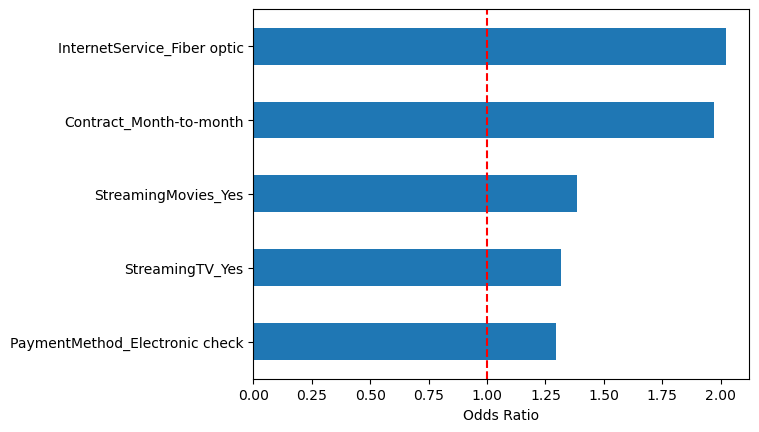

In [452]:
odds_ratio.tail().plot(kind="barh")
plt.axvline(x=1, linestyle="--", color="red")
plt.xlabel("Odds Ratio");

From the chart above, we can see that the highest predictors of our model are **InternetService_Fiber optic** and **Contract_Month-to-month** Looking at odds_ratio 1, the chart indicates that if an **InternetService** of **Fibre optic** is provided to a customer, the odds of them churning or not patronising this business is **2 times** that of other customers, all things being equal. So if an **InternetService** of **Fibre optic** is provided to a customer, the chances of the customer leaving the business is **200%**. While that for **Month-to-month** of **Contract** is about **190%**

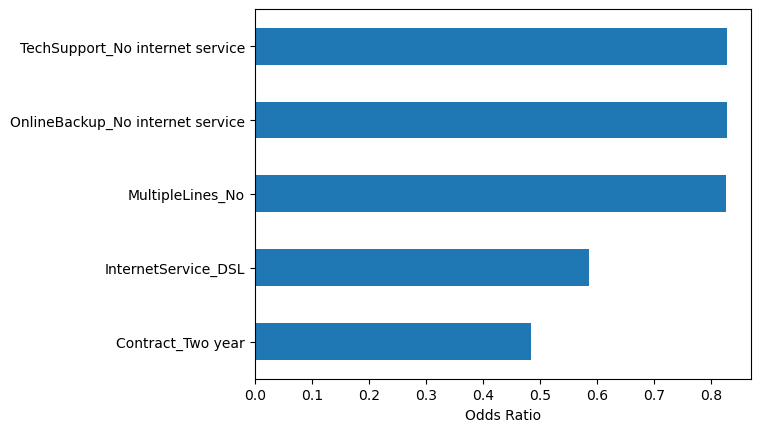

In [454]:
odds_ratio.head().plot(kind="barh")
plt.xlabel("Odds Ratio");

The least here are **InternetService_DSL** and **Contract_Two year**. For InternetService_DSL, 1 minus 0.6 is 0.4, so if a Customer is provided an **InternetService** of **DSL**, the chances of them not to churn, that is the chances of them staying and remaining with the business is **40%**, and if there are offered a **Two year** **Contract**, there is **50%** chance that they are staying back as reliable customers.